11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Shape : (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7854 - loss: 0.2422 - val_accuracy: 0.8053 - val_loss: 0.1540
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8085 - loss: 0.1334 - val_accuracy: 0.8113 - val_loss: 0.1208
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8118 - loss: 0.1128 - val_accuracy: 0.8137 - val_loss: 0.1083
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8129 - loss: 0.1037 - val_accuracy: 0.8136 - val_loss: 0.1022
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8135 - loss: 0.0984 - val_accuracy: 0.8144 - val_loss: 0.0968
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8129 - loss: 0.0948

Test Loss : 0.09481222927570343
Test Accuracy : 0.8128887414932251


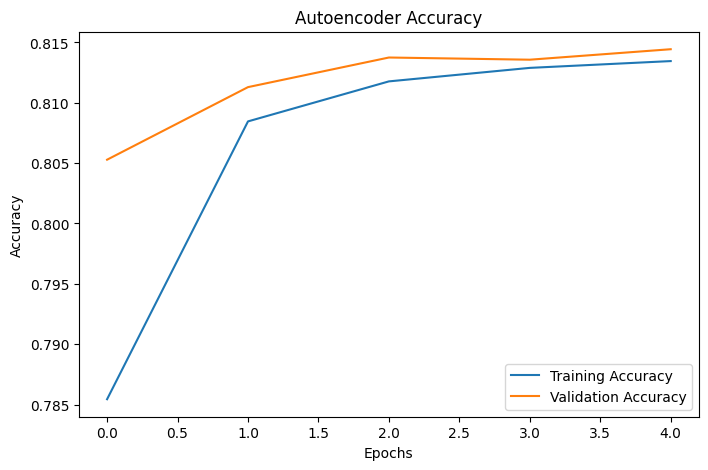

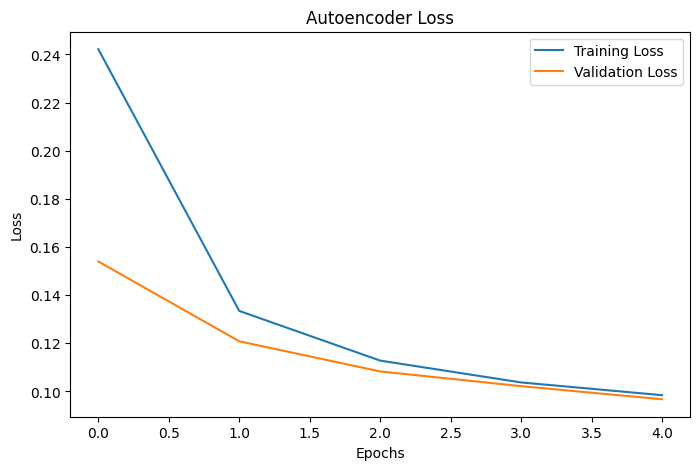

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


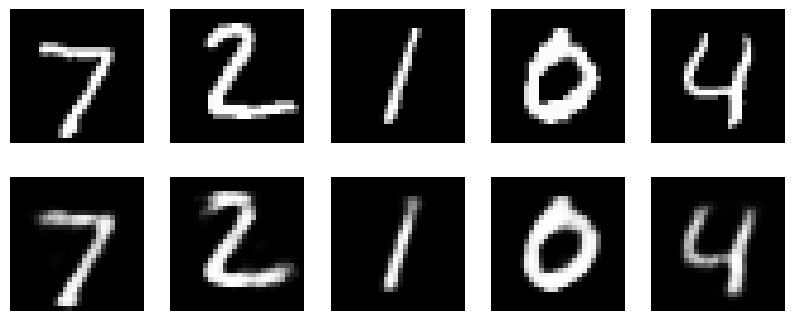

In [1]:
# Experiment No. 10
# Title: Unsupervised Generative Models using Autoencoder

# Aim:
# To implement an Unsupervised Generative Model using
# Autoencoder architecture in TensorFlow and Keras.

# Import Required Libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Reshape

# Load MNIST Dataset
(X_train, _), (X_test, _) = mnist.load_data()

# Normalize Dataset
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape Dataset
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

# Encoder
encoder_input = Input(shape=(28,28,1))

x = Flatten()(encoder_input)

x = Dense(
    128,
    activation='relu'
)(x)

encoded = Dense(
    64,
    activation='relu'
)(x)

# Decoder
x = Dense(
    128,
    activation='relu'
)(encoded)

x = Dense(
    28 * 28,
    activation='sigmoid'
)(x)

decoded = Reshape((28,28,1))(x)

# Build Autoencoder Model
autoencoder = Model(
    encoder_input,
    decoded
)

# Model Summary
autoencoder.summary()

# Compile Model
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = autoencoder.fit(
    X_train,
    X_train,
    epochs=5,
    batch_size=256,
    validation_split=0.2
)

# Evaluate Model
loss, accuracy = autoencoder.evaluate(
    X_test,
    X_test
)

print("\nTest Loss :", loss)
print("Test Accuracy :", accuracy)

# Plot Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Autoencoder Accuracy')
plt.legend()

plt.show()

# Plot Loss Graph
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Autoencoder Loss')
plt.legend()

plt.show()

# Generate Reconstructed Images
decoded_images = autoencoder.predict(
    X_test[:5]
)

# Display Original and Reconstructed Images
plt.figure(figsize=(10,4))

for i in range(5):

    # Original Image
    plt.subplot(2,5,i+1)

    plt.imshow(
        X_test[i].reshape(28,28),
        cmap='gray'
    )

    plt.axis('off')

    # Reconstructed Image
    plt.subplot(2,5,i+6)

    plt.imshow(
        decoded_images[i].reshape(28,28),
        cmap='gray'
    )

    plt.axis('off')

plt.show()

# Conclusion
# Successfully implemented an Unsupervised Generative Model
# using Autoencoder architecture in TensorFlow and Keras.